In [ ]:
pip install pandas numpy scikit-learn xgboost

In [ ]:
import pandas as pd
import numpy as np

train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

print(train.head())
print(train.info())

       ID  electricity_kwh_per_month  natural_gas_therms_per_month  \
0   0xd6c                     759.70                         55.95   
1  0x3fdf                     387.06                         70.59   
2  0x3b08                     594.25                         29.14   
3  0x31e5                     503.76                         74.68   
4  0x397e                     549.54                        -77.00   

   vehicle_miles_per_month house_area_sqft  water_usage_liters_per_day  \
0                   944.55         2422.07                      541.27   
1                  1280.85          1995.3                      280.39   
2                  1005.72         2673.55                      416.14   
3                  1049.46         2994.28                      530.13   
4                   756.49         2549.57                      604.10   

   public_transport_usage_per_week household_size  home_insulation_quality  \
0                                1              3       

In [ ]:
null_cols=train.columns[train.isnull().any()]
df_test=test

for col in null_cols:
    train[col].fillna(train[col].median(), inplace=True)

<ipython-input-60-20bcaefdeb24>:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].median(), inplace=True)


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode categorical columns
df_test['heating_type'] = label_encoder.fit_transform(df_test['heating_type'])
df_test['diet_type'] = label_encoder.fit_transform(df_test['diet_type'])
df_test['household_size'] = label_encoder.fit_transform(df_test['diet_type'])
df_test['house_area_sqft'] = label_encoder.fit_transform(df_test['diet_type'])
print(df_test.dtypes)


electricity_kwh_per_month          float64
natural_gas_therms_per_month       float64
vehicle_miles_per_month            float64
house_area_sqft                      int64
water_usage_liters_per_day         float64
public_transport_usage_per_week      int64
household_size                       int64
home_insulation_quality              int64
meat_consumption_kg_per_week       float64
laundry_loads_per_week               int64
recycles_regularly                 float64
composts_organic_waste             float64
uses_solar_panels                    int64
energy_efficient_appliances        float64
heating_type                         int64
diet_type                            int64
owns_pet                             int64
smart_thermostat_installed         float64
dtype: object


In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Load your cleaned dataset
df = train # or use your DataFrame directly

# Convert these object columns to numeric
df['house_area_sqft'] = pd.to_numeric(df['house_area_sqft'], errors='coerce')
df['household_size'] = pd.to_numeric(df['household_size'], errors='coerce')

# Optionally handle any resulting NaNs
df.dropna(inplace=True)



# Convert categorical columns
categorical_cols = ['heating_type', 'diet_type']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df['total_energy_use'] = df['electricity_kwh_per_month'] + df['natural_gas_therms_per_month']
df['energy_per_person'] = df['total_energy_use'] / df['household_size']
df['water_per_person'] = df['water_usage_liters_per_day'] / df['household_size']
df['area_per_person'] = df['house_area_sqft'] / df['household_size']
df['transport_intensity'] = df['vehicle_miles_per_month'] / (df['public_transport_usage_per_week'] + 1)
df['eco_friendly_behavior'] = df['recycles_regularly'] + df['composts_organic_waste'] + df['uses_solar_panels'] + df['energy_efficient_appliances'] + df['smart_thermostat_installed']

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

engineered_cols = ['energy_per_person', 'water_per_person', 'area_per_person', 'transport_intensity']
scaler = StandardScaler()
df[engineered_cols] = scaler.fit_transform(df[engineered_cols])

df[engineered_cols] = df[engineered_cols].round(2)
# Define features and target
X = df.drop(['ID', 'carbon_footprint'], axis=1)
y = df['carbon_footprint']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train model
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


RMSE: 66.38900884255689
R2 Score: 0.8804906674534808


In [ ]:
len(test['ID'])
# Step 1: Predict on test data
test_predictions = model.predict(X_test).round(2)
print(test_predictions)

[895.69 617.69 875.9  ... 587.24 866.07 565.04]


In [ ]:
# Assuming you have:
# - test_df as your test DataFrame
# - model as your trained model
# - preprocessed test data in X_test
# - original test_df has 'ID' column



# Step 2: Create submission DataFrame
# Make sure to exclude 'carbon_footprint' from the test data when making predictions
df_test = df_test.drop(columns=['carbon_footprint'], errors='ignore')  # Ignore if not present in test data

test_predictions = model.predict(df_test).round(2)
submission = pd.DataFrame({
    'ID': test['ID'],
    'carbon_footprint': test_predictions
})

# Step 3: Save as CSV
submission.to_csv('submission.csv', index=False)


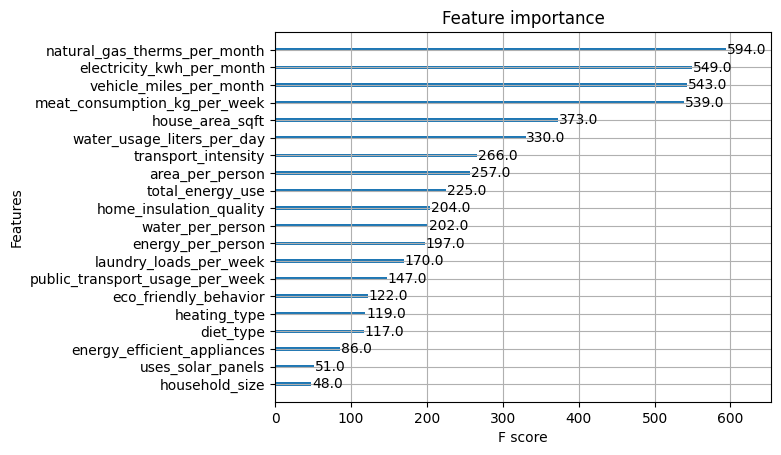

In [ ]:
import matplotlib.pyplot as plt
xgb.plot_importance(model, max_num_features=20)
plt.show()


In [ ]:
submission = pd.read_csv('submission.csv')
print(len(submission['ID']))

6000
